In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import warnings

In [5]:
class HEMSEnvRealWeather(gym.Env):
    metadata = {"render.modes": ["human"]}

    def __init__(self, load_path="House16.csv", solar_path="solar.csv", step_minutes=10, max_battery_kwh=10.0,
                 battery_charge_eff=0.95, battery_discharge_eff=0.95, battery_deg_cost_per_kwh=0.01):
        super().__init__()
        self.load_df = pd.read_csv(load_path, parse_dates=["Date_Time"])
        self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])
        
        # Clean up column names to remove any hidden whitespace
        self.load_df.columns = self.load_df.columns.str.strip()
        self.solar_df.columns = self.solar_df.columns.str.strip()
        
        self.n_steps = min(len(self.load_df), len(self.solar_df))
        self.step_minutes = step_minutes
        self.dt_hours = step_minutes / 60.0
        self.max_battery = float(max_battery_kwh)
        self.battery_charge_eff = battery_charge_eff
        self.battery_discharge_eff = battery_discharge_eff
        self.battery_deg_cost_per_kwh = float(battery_deg_cost_per_kwh)
        self.action_space = spaces.Discrete(4)
        obs_low = np.array([0.0, 0.0, 0.0, -1.0, -1.0], dtype=np.float32)
        obs_high = np.array([1e6, 1e6, 1.0, 1.0, 1.0], dtype=np.float32)
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)
        
        self.time_step = 0
        self.battery_soc = 0.0
        self.episode_info = []

    def _compute_solar_output_kw(self, solar_row):
        # *** DEFINITIVE FIX: Calculating solar kW from your file's actual columns ***
        ghi = pd.to_numeric(solar_row.get("ghi_pyr"), errors='coerce')
        humidity = pd.to_numeric(solar_row.get("relative_humidity"), errors='coerce')

        if pd.isna(ghi) or pd.isna(humidity):
            return 0.0

        # Assumed parameters for the solar panel system
        panel_area_sq_m = 10.0
        panel_efficiency = 0.18
        
        # Using humidity as a proxy for weather conditions affecting efficiency
        weather_factor = max(0.0, 1.0 - (humidity / 100.0))

        # Standard formula to convert irradiance (W/m^2) to power (kW)
        pv_kw = (ghi * panel_area_sq_m * panel_efficiency * weather_factor) / 1000.0
        
        return max(pv_kw, 0.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.time_step = 0
        self.battery_soc = 0.5 * self.max_battery
        self.episode_info = []
        return self._get_obs()

    def _get_obs(self):
        idx = min(self.time_step, self.n_steps - 1)
        load_row = self.load_df.iloc[idx]
        solar_row = self.solar_df.iloc[idx]
        load_kw = float(load_row.get("Usage_kW", 0.0))
        solar_kw = self._compute_solar_output_kw(solar_row)
        soc_norm = self.battery_soc / self.max_battery if self.max_battery > 0 else 0.0
        ts = load_row.get("Date_Time")
        hour = ts.hour if pd.notna(ts) else (idx * self.step_minutes // 60) % 24
        hour_rad = (2.0 * math.pi * hour) / 24.0
        obs = np.array([load_kw, solar_kw, soc_norm, math.sin(hour_rad), math.cos(hour_rad)], dtype=np.float32)
        return obs, {}

    def _get_grid_price_for_hour(self, hour):
        return 46.85 if 19 <= hour <= 23 else 40.53

    def step(self, action):
        idx = min(self.time_step, self.n_steps - 1)
        load_row, solar_row = self.load_df.iloc[idx], self.solar_df.iloc[idx]
        load_kwh = float(load_row.get("Usage_kW", 0.0)) * self.dt_hours
        solar_kwh_available = self._compute_solar_output_kw(solar_row) * self.dt_hours
        ts = load_row.get("Date_Time")
        hour = ts.hour if pd.notna(ts) else (idx * self.step_minutes // 60) % 24
        grid_price = self._get_grid_price_for_hour(hour)
        
        grid_energy, solar_supplied, battery_supplied, battery_discharge = 0.0, 0.0, 0.0, 0.0
        remaining_load = load_kwh

        if action == 0 or action == 2: # Solar/Auto Priority
            solar_supplied = min(solar_kwh_available, remaining_load)
            remaining_load -= solar_supplied
            if self.battery_soc > 0 and remaining_load > 0 and self.battery_discharge_eff > 0:
                discharge = min(self.battery_soc, remaining_load / self.battery_discharge_eff)
                battery_discharge, battery_supplied = discharge, discharge * self.battery_discharge_eff
                self.battery_soc -= discharge
                remaining_load -= battery_supplied
            if remaining_load > 0:
                grid_energy = remaining_load
            if solar_kwh_available > solar_supplied:
                charge = min((solar_kwh_available - solar_supplied) * self.battery_charge_eff, self.max_battery - self.battery_soc)
                self.battery_soc += charge
        elif action == 1: # Battery Priority
            if self.battery_soc > 0 and remaining_load > 0 and self.battery_discharge_eff > 0:
                discharge = min(self.battery_soc, remaining_load / self.battery_discharge_eff)
                battery_discharge, battery_supplied = discharge, discharge * self.battery_discharge_eff
                self.battery_soc -= discharge
                remaining_load -= battery_supplied
            if remaining_load > 0:
                solar_supplied = min(solar_kwh_available, remaining_load)
                remaining_load -= solar_supplied
            if remaining_load > 0:
                grid_energy = remaining_load
        elif action == 3: # Grid Force
            grid_energy = remaining_load

        grid_cost = grid_energy * grid_price
        battery_deg_cost = battery_discharge * self.battery_deg_cost_per_kwh
        total_cost = grid_cost + battery_deg_cost
        reward = -total_cost
        
        info = {
            "action": int(action), "battery_soc": self.battery_soc, "solar_supplied": solar_supplied,
            "battery_supplied": battery_supplied, "grid_energy": grid_energy, "grid_cost": grid_cost,
            "battery_deg_cost": battery_deg_cost, "total_cost_this_step": total_cost,
        }
        self.episode_info.append(info)
        
        self.time_step += 1
        terminated = self.time_step >= self.n_steps
        obs, _ = self._get_obs()
        return obs, reward, terminated, False, info

C:\Users\Osama\AppData\Local\Temp\ipykernel_29700\1394378916.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])
C:\Users\Osama\AppData\Local\Temp\ipykernel_29700\1394378916.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])
C:\Users\Osama\AppData\Local\Temp\ipykernel_29700\1394378916.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])
C:\Users\Osama\AppData\Local\Temp\ipykernel_29700\1394378916.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])


Training the PPO model...
Training complete.

--- Starting Final Evaluation ---


C:\Users\Osama\AppData\Local\Temp\ipykernel_29700\1394378916.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  self.solar_df = pd.read_csv(solar_path, parse_dates=["time"])



=== PPO Agent Cost Summary ===
Total Grid Cost: 2553503.23 PKR
Total Battery Degradation Cost: 0.29 PKR
**Total System Cost**: 2553503.52 PKR

=== PPO Agent Energy Summary ===
Energy Supplied by Solar: 3136.22 kWh
Energy Supplied by Battery: 27.58 kWh
Final Battery SOC: 0.00 kWh

Generating plots...

Plots saved as 'summary_plot.png' and 'soc_cumulative_cost.png'.


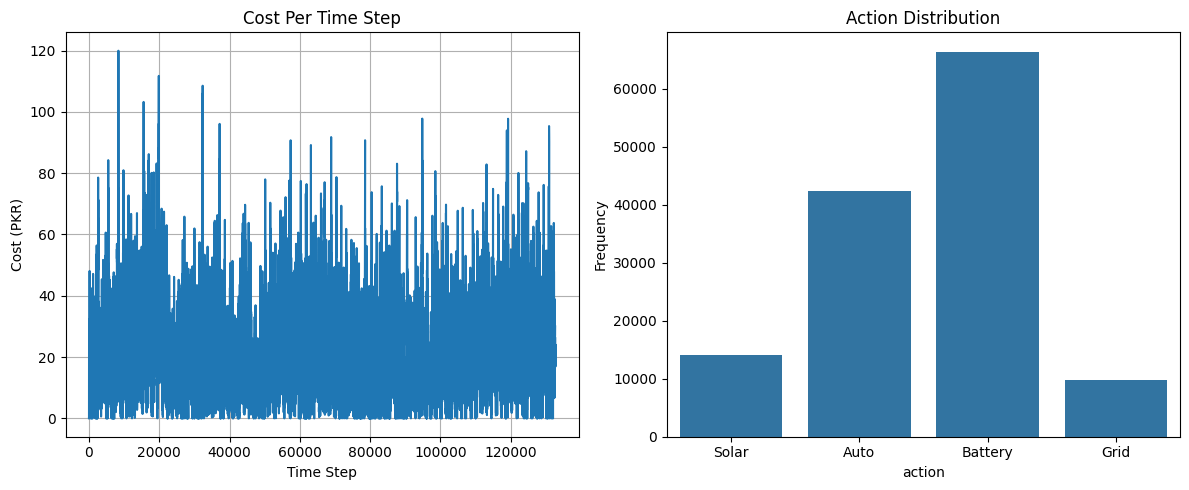

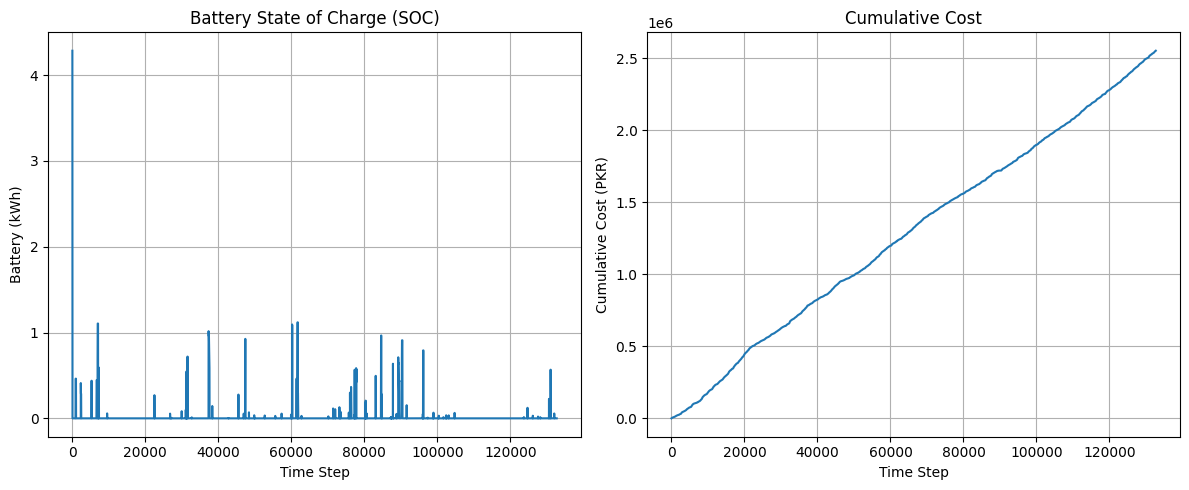

In [6]:
def make_env():
    return HEMSEnvRealWeather()

# --- Main execution block ---
if __name__ == "__main__":
    vec_env = DummyVecEnv([make_env for _ in range(4)])
    vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.0)
    model = PPO("MlpPolicy", vec_env, policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])), verbose=0)
    print("Training the PPO model...")
    model.learn(total_timesteps=2000000)
    model.save("ppo_hems_model_final")
    vec_env.save("vecnormalize_final.pkl")
    print("Training complete.")

    print("\n--- Starting Final Evaluation ---")
    model = PPO.load("ppo_hems_model_final")
    eval_vec_env = DummyVecEnv([make_env])
    eval_vec_env = VecNormalize.load("vecnormalize_final.pkl", eval_vec_env)
    eval_vec_env.training = False
    eval_vec_env.norm_reward = False
    
    all_infos = []
    obs = eval_vec_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, info = eval_vec_env.step(action)
        all_infos.append(info[0])
        done = terminated[0]

    results_df = pd.DataFrame(all_infos)
    
    # --- Detailed Evaluation Summary ---
    total_grid_cost = results_df['grid_cost'].sum()
    total_deg_cost = results_df['battery_deg_cost'].sum()
    total_system_cost = results_df['total_cost_this_step'].sum()
    total_solar_supplied = results_df['solar_supplied'].sum()
    total_battery_supplied = results_df['battery_supplied'].sum()
    final_soc = results_df['battery_soc'].iloc[-1] if not results_df.empty else 0.0
    
    print("\n=== PPO Agent Cost Summary ===")
    print(f"Total Grid Cost: {total_grid_cost:.2f} PKR")
    print(f"Total Battery Degradation Cost: {total_deg_cost:.2f} PKR")
    print(f"**Total System Cost**: {total_system_cost:.2f} PKR")
    
    print("\n=== PPO Agent Energy Summary ===")
    print(f"Energy Supplied by Solar: {total_solar_supplied:.2f} kWh")
    print(f"Energy Supplied by Battery: {total_battery_supplied:.2f} kWh")
    print(f"Final Battery SOC: {final_soc:.2f} kWh")

    # --- Plotting ---
    action_labels = {0: 'Solar', 1: 'Battery', 2: 'Auto', 3: 'Grid'}
    print("\nGenerating plots...")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
    results_df['total_cost_this_step'].plot(ax=axes[0], title="Cost Per Time Step", grid=True)
    axes[0].set_xlabel("Time Step"); axes[0].set_ylabel("Cost (PKR)")
    
    action_counts = results_df['action'].map(action_labels).value_counts()
    sns.barplot(x=action_counts.index, y=action_counts.values, ax=axes[1], order=['Solar', 'Auto', 'Battery', 'Grid'])
    axes[1].set_title("Action Distribution"); axes[1].set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("summary_plot.png")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
    results_df['battery_soc'].plot(ax=axes[0], title="Battery State of Charge (SOC)", grid=True)
    axes[0].set_xlabel("Time Step"); axes[0].set_ylabel("Battery (kWh)")
    results_df['total_cost_this_step'].cumsum().plot(ax=axes[1], title="Cumulative Cost", grid=True)
    axes[1].set_xlabel("Time Step"); axes[1].set_ylabel("Cumulative Cost (PKR)")
    plt.tight_layout()
    plt.savefig("soc_cumulative_cost.png")

    print("\nPlots saved as 'summary_plot.png' and 'soc_cumulative_cost.png'.")
    plt.show()